In [1]:
import numpy as np
from scipy.optimize import least_squares
np.random.seed(1001)
import pandas as pd
import geopandas as gpd
import math
import random

import matplotlib.pyplot as plt

C:\Users\z3258367\AppData\Local\Temp\ipykernel_71708\836215747.py:5: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [2]:
folder = "C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\"
features = gpd.read_file((folder + 
    "Colouring data & results\\Sydney WalkTHERE results\\Sydney avg MB employment results.gpkg"))
features = features.dropna()

mode_data = pd.read_csv(("C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Data\\" + 
    "ABS Data\\Sydney GCCSA MBs Work Travel Mode.csv"))

mode_data = mode_data.set_index('MB_Code16')

features['MB_CODE16'] = features['MB_CODE16'].astype('int64')

data = features.join(mode_data, on="MB_CODE16")

Total workers is the total by all modes, excluding overseas visitors and those who did not work or did not answer the question. It does include people who worked from home. It will not align with the ABS 'total' column (even after excluding the above categories) because of the ABS censorship of small values.

In [3]:
data['total_workers'] = data.iloc[:,26:259].sum(axis=1)

c:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\geodataframe.py:1443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


In [4]:
data = data[data['total_workers']>0]

In [5]:
data['walk_prop'] = data['Walked only']/data['total_workers']

c:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\geodataframe.py:1443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


In [6]:
# getting rid of columns that are entirely empty/0 responses with that combination of modes
data = data.iloc[:,:25].join(data.iloc[:,26:266].loc[:,data.iloc[:,26:266].sum() > 0])

In [7]:
# manually fixing Holsworthy jobs number, I can't remember why it's wrong
data.loc[25470,'Jobs_mean'] = 2483

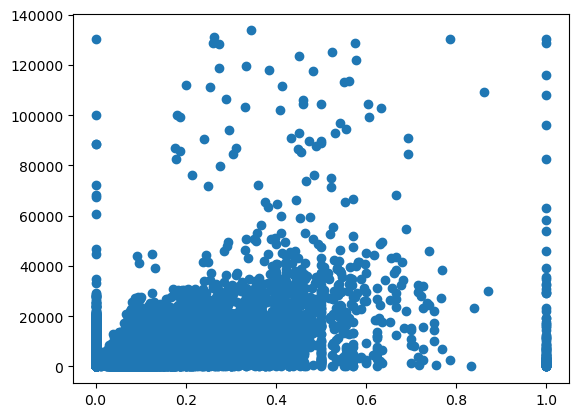

In [8]:
fig, ax = plt.subplots()
ax.scatter(data['Walked only']/data['total_workers'], data['Jobs_mean'])

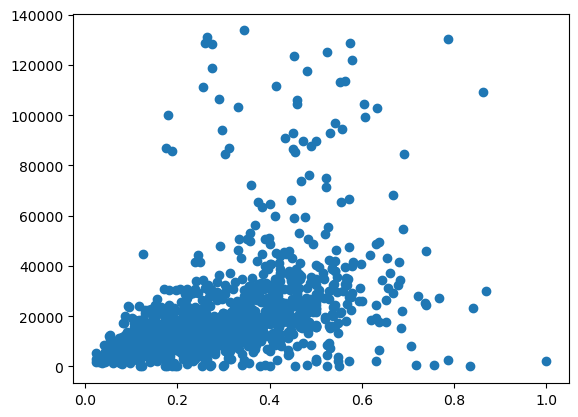

In [9]:
# limiting to meshblocks with more than 10 workers just for easier viewing of trend
fig, ax = plt.subplots()
ax.scatter(data[data['Walked only']>10]['Walked only']/data[data['Walked only']>10]['total_workers'], data[data['Walked only']>10]['Jobs_mean'])

In [10]:
# mean number of jobs accessible from MBs where anyone walked to work
data[data['Walked only']>0]['Jobs_mean'].mean()

6824.304635791853

In [11]:
# mean number of jobs accessible from MBs where no one walked to work
data[data['Walked only']==0]['Jobs_mean'].mean()

1616.6771271420198

### Modelling begins here

In [12]:
init_coeff = np.array([-0.00001, 0.004])
# diminishing returns constant, scaling constant
nb_features = len(init_coeff)

print("Number of features: ", nb_features)

Number of features:  2


In [13]:
walk_trips = data['Walked only']
total_workers = data['total_workers']
jobs = data['Jobs_mean']

In [14]:
data10 = data[data['Walked only']>10]
data5 = data[data['Walked only']>5]

In [15]:
len(total_workers), len(walk_trips), len(jobs)

(45439, 45439, 45439)

In [16]:
# Define the cost function
def exp1_model(c, total_workers, jobs):
    score_model = total_workers*(1 - np.exp(jobs*c[0]))
    return score_model

def exp1(c):
    score_model = exp1_model(c, total_workers, jobs)
    residual = walk_trips - score_model
    return residual

In [17]:
def get_rsq(f, y):
#fitted values, observations
    ss_res = np.dot((y - f),(y - f))
    ymean = np.mean(y)
    ss_tot = np.dot((y - ymean),(y - ymean))
    return 1 - ss_res/ss_tot

In [18]:
exp1p = least_squares(exp1, init_coeff, method='lm', verbose=2)
print("Estimates  ", exp1p.x)
get_rsq(exp1_model(exp1p.x, total_workers, jobs), walk_trips)

`ftol` termination condition is satisfied.
Function evaluations 16, initial cost 2.5955e+05, final cost 2.4614e+05, first-order optimality 4.49e+08.
Estimates   [-1.18106573e-05  4.00000000e-03]


0.7822289961259826

In [19]:
str(exp1p.x[0].round(8))

'-1.181e-05'

In [20]:
def get_w_rsq(f, y, total_workers):
#fitted values, observations
    ss_res = np.dot((y*total_workers - f*total_workers),(y*total_workers - f*total_workers))
    ymean = np.mean(y*total_workers)
    ss_tot = np.dot((y*total_workers - ymean),(y*total_workers - ymean))
    return 1 - ss_res/ss_tot

In [21]:
# Define the cost function
def exp1w_model(c, total_workers, jobs):
    score_model = total_workers*(1 - np.exp(jobs*c[0]))
    return score_model

def exp1w(c):
    score_model = exp1_model(c, total_workers, jobs)
    residual = walk_trips*total_workers - score_model*total_workers
    return residual

In [22]:
exp1wp = least_squares(exp1w, init_coeff, method='lm', verbose=2)
print("Estimates  ", exp1wp.x)
get_w_rsq(exp1w_model(exp1wp.x, total_workers, jobs), walk_trips, total_workers)

Both `ftol` and `xtol` termination conditions are satisfied.
Function evaluations 13, initial cost 2.6721e+10, final cost 2.4779e+10, first-order optimality 2.12e+13.
Estimates   [-1.14175225e-05  4.00000000e-03]


0.8928437220134119

In [23]:
# Define the cost function
def exp2_model(c, total_workers, jobs):
    score_model = total_workers*(1 - np.exp(jobs*c[0]))*c[1]
    return score_model

def exp2(c):
    score_model = exp2_model(c, total_workers, jobs)
    residual = walk_trips - score_model
    return residual

In [24]:
init_coeff = [-0.00005, 0.5]
exp2p = least_squares(exp2, init_coeff, method='lm', verbose=2)
print("Estimates  ", exp2p.x)
get_rsq(exp2_model(exp2p.x, total_workers, jobs), walk_trips), get_rsq(exp2_model(exp2p.x, total_workers, jobs)/total_workers, walk_trips/total_workers)

`ftol` termination condition is satisfied.
Function evaluations 25, initial cost 2.8724e+05, final cost 2.1674e+05, first-order optimality 6.85e+05.
Estimates   [-2.76630285e-05  5.64123783e-01]


(0.8082388869106396, 0.3465689352800859)

In [25]:
# Define the cost function
def exp2w_model(c, total_workers, jobs):
    score_model = total_workers*(1 - np.exp(jobs*c[0]))*c[1]
    return score_model

def exp2w(c):
    score_model = exp2w_model(c, total_workers, jobs)
    residual = walk_trips*total_workers - score_model*total_workers
    return residual

In [26]:
init_coeff = [-0.00005, 0.5]
exp2wp = least_squares(exp2w, init_coeff, method='lm', verbose=2)
print("Estimates  ", exp2wp.x)
get_w_rsq(exp2w_model(exp2wp.x, total_workers, jobs), walk_trips, total_workers)

`ftol` termination condition is satisfied.
Function evaluations 29, initial cost 4.4783e+10, final cost 2.4347e+10, first-order optimality 2.35e+12.
Estimates   [-1.63536767e-05  7.70457207e-01]


0.8947144324870677

In [27]:
#2 coefficient with one removed
estimate_1 = total_workers*(1 - np.exp(jobs*exp2wp.x[0]))
get_rsq(estimate_1/total_workers, walk_trips/total_workers), get_w_rsq(total_workers*(1 - np.exp(jobs*exp2wp.x[0])), walk_trips, total_workers)

(0.3244597032570883, 0.8149919762957182)

In [28]:
def flat_model(c, total_workers):
    score_model = total_workers*c[1]
    return score_model

def flat(c):
    score_model = flat_model(c, total_workers)
    residual = walk_trips - score_model
    return residual

In [29]:
flatp = least_squares(flat, init_coeff, method='lm', verbose=2)
print("Estimates  ", flatp.x)
get_rsq(flat_model(flatp.x, total_workers), walk_trips)

`gtol` termination condition is satisfied.
Function evaluations 6, initial cost 1.3380e+07, final cost 9.2318e+05, first-order optimality 1.17e-04.
Estimates   [-5.0000000e-05  6.4666759e-02]


0.18321536587705878

In [30]:
estimated = total_workers*flatp.x[1]

## Graphs

In [31]:
subdata = random.sample(list(data5.index), int(round(0.5*len(data5),0)))

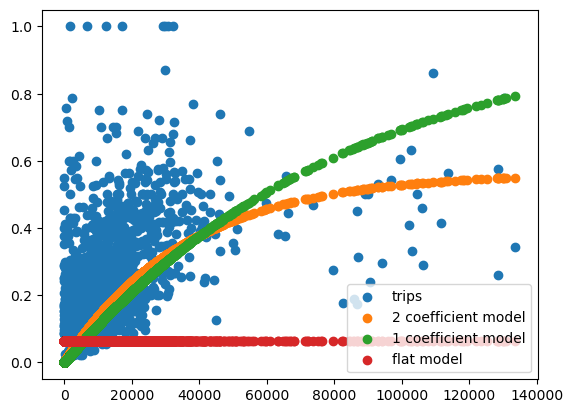

In [32]:
fig, ax = plt.subplots()
ax.scatter(data.loc[subdata, 'Jobs_mean'], data.loc[subdata, 'Walked only']/data.loc[subdata, 'total_workers'])
ax.scatter(data['Jobs_mean'], exp2_model(exp2p.x, total_workers, jobs)/data['total_workers'])
ax.scatter(data['Jobs_mean'], exp1_model(exp1p.x, total_workers, jobs)/data['total_workers'])
ax.scatter(data['Jobs_mean'], flat_model(flatp.x, total_workers)/data['total_workers'])
ax.legend(["trips", "2 coefficient model","1 coefficient model","flat model"],loc ="lower right")

In [33]:
model_jobs = np.arange(0, 300000, 1000)

Text(0.5, 0, 'Number of walking distance-weighted jobs available')

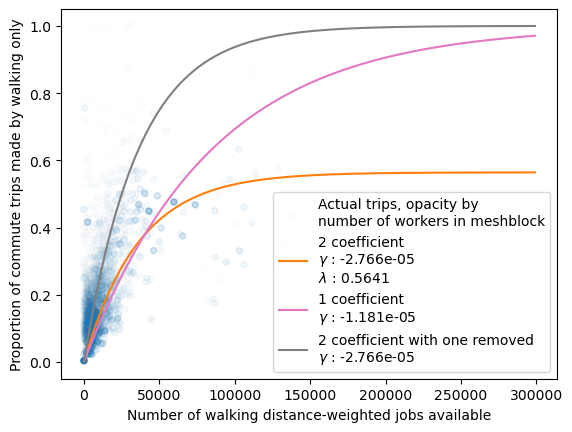

In [34]:
fig, ax = plt.subplots()
ax.scatter(data.loc[subdata, 'Jobs_mean'], data.loc[subdata, 'Walked only']/data.loc[subdata, 'total_workers'],
           #c=data.loc[subdata, 'total_workers'], cmap='Reds',
           alpha=data.loc[subdata, 'total_workers']/max(data.loc[subdata, 'total_workers']),
           c='#1f77b4',
           s=20, label="Actual trips, opacity by \nnumber of workers in meshblock")
ax.plot(model_jobs, (1 - np.exp(model_jobs*exp2p.x[0]))*exp2p.x[1], 
        label=("2 coefficient\n" +
               r'$\gamma$ : '+str(exp2p.x[0].round(8)) + "\n"+ 
               r'$\lambda$ : '+ str(exp2p.x[1].round(4))),
       c='#ff7f0e')
ax.plot(model_jobs, (1 - np.exp(model_jobs*exp1p.x[0])), 
        label=("1 coefficient \n" + 
        r'$\gamma$ : '+str(exp1p.x[0].round(8))),
       c='#e377c2')
ax.plot(model_jobs, (1 - np.exp(model_jobs*exp2p.x[0])), 
        label=("2 coefficient with one removed \n" + 
        r'$\gamma$ : '+str(exp2p.x[0].round(8))),
       c='grey')

#ax.scatter(data10['Jobs_mean'], exp2_model(exp2wp.x, total_workers, jobs)/data10['total_workers'])
#ax.scatter(data10['Jobs_mean'], exp1_model(exp1wp.x, total_workers, jobs)/data10['total_workers'])
#ax.scatter(data10['Jobs_mean'], flat_model(flatp.x, total_workers)/data10['total_workers'])
ax.legend(loc ="lower right")
ax.set_ylabel('Proportion of commute trips made by walking only')
ax.set_xlabel('Number of walking distance-weighted jobs available')

Text(0.5, 0, 'Number of walking distance-weighted jobs available')

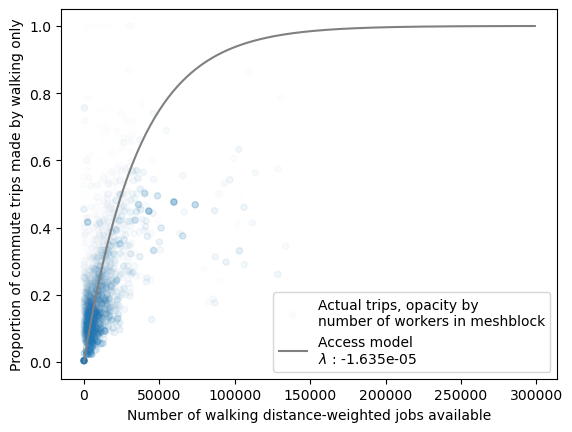

In [35]:
fig, ax = plt.subplots()
ax.scatter(data.loc[subdata, 'Jobs_mean'], data.loc[subdata, 'Walked only']/data.loc[subdata, 'total_workers'],
           #c=data.loc[subdata, 'total_workers'], cmap='Reds',
           alpha=data.loc[subdata, 'total_workers']/max(data.loc[subdata, 'total_workers']),
           c='#1f77b4',
           s=20, label="Actual trips, opacity by \nnumber of workers in meshblock")

ax.plot(model_jobs, (1 - np.exp(model_jobs*exp2p.x[0])), 
        label=("Access model \n" + 
        r'$\lambda$ : '+str(exp2wp.x[0].round(8))),
       c='grey')

#ax.scatter(data10['Jobs_mean'], exp2_model(exp2wp.x, total_workers, jobs)/data10['total_workers'])
#ax.scatter(data10['Jobs_mean'], exp1_model(exp1wp.x, total_workers, jobs)/data10['total_workers'])
#ax.scatter(data10['Jobs_mean'], flat_model(flatp.x, total_workers)/data10['total_workers'])
ax.legend(loc ="lower right")
ax.set_ylabel('Proportion of commute trips made by walking only')
ax.set_xlabel('Number of walking distance-weighted jobs available')

In [36]:
shops = np.arange(0, 15, 1)
shop_lambda = 0.3
marginal = [(-np.exp(-(shop)*shop_lambda) + np.exp(-((shop-1)*shop_lambda))) for shop in shops[:]]
marginal[0] = 0

In [37]:
[(1- np.exp(-(shop)*shop_lambda)) for shop in shops[:]]

[0.0,
 0.2591817793182821,
 0.4511883639059735,
 0.5934303402594008,
 0.6988057880877978,
 0.7768698398515702,
 0.8347011117784134,
 0.8775435717470181,
 0.9092820467105875,
 0.9327944872602503,
 0.950212931632136,
 0.96311683259876,
 0.9726762775527075,
 0.9797580885541957,
 0.9850044231795223]

In [38]:
[(1- np.exp(-((shop-1)*shop_lambda))) for shop in shops[:]]

[-0.3498588075760032,
 0.0,
 0.2591817793182821,
 0.4511883639059735,
 0.5934303402594008,
 0.6988057880877978,
 0.7768698398515702,
 0.8347011117784134,
 0.8775435717470181,
 0.9092820467105875,
 0.9327944872602503,
 0.950212931632136,
 0.96311683259876,
 0.9726762775527075,
 0.9797580885541957]

In [39]:
marginal

[0,
 0.2591817793182821,
 0.19200658458769138,
 0.14224197635342734,
 0.10537544782839703,
 0.07806405176377232,
 0.05783127192684326,
 0.042842459968604654,
 0.031738474963569394,
 0.023512440549662728,
 0.01741844437188584,
 0.01290390096662393,
 0.009559444953947446,
 0.007081811001488178,
 0.005246334625326688]

Text(0.5, 0, 'Number of walking distance-weighted shops available')

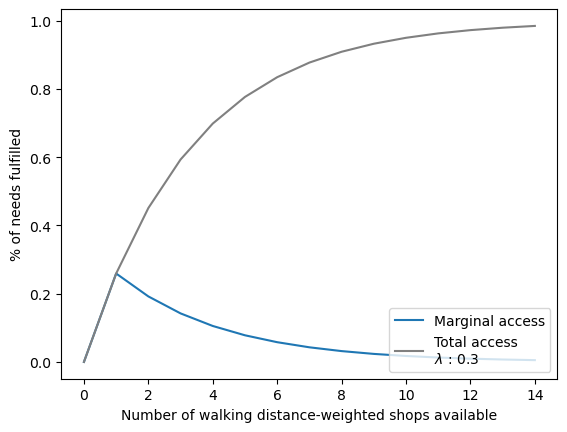

In [40]:
fig, ax = plt.subplots()
ax.plot(shops, marginal,
           #c=data.loc[subdata, 'total_workers'], cmap='Reds',
           c='#1f77b4',
           label="Marginal access")

ax.plot(shops, (1 - np.exp(-shops*shop_lambda)), 
        label=("Total access \n" + 
        r'$\lambda$ : '+str(shop_lambda)),
       c='grey')

#ax.scatter(data10['Jobs_mean'], exp2_model(exp2wp.x, total_workers, jobs)/data10['total_workers'])
#ax.scatter(data10['Jobs_mean'], exp1_model(exp1wp.x, total_workers, jobs)/data10['total_workers'])
#ax.scatter(data10['Jobs_mean'], flat_model(flatp.x, total_workers)/data10['total_workers'])
ax.legend(loc ="lower right")
ax.set_ylabel('% of needs fulfilled')
ax.set_xlabel('Number of walking distance-weighted shops available')

Text(0.5, 0, 'Number of walking distance-weighted jobs available')

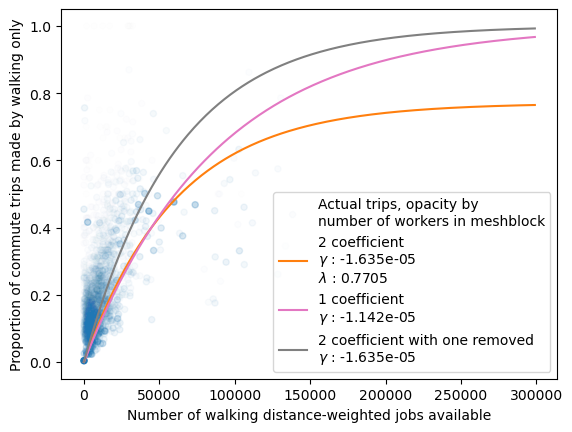

In [41]:
fig, ax = plt.subplots()
ax.scatter(data.loc[subdata, 'Jobs_mean'], data.loc[subdata, 'Walked only']/data.loc[subdata, 'total_workers'],
           #c=data.loc[subdata, 'total_workers'], cmap='Reds',
           alpha=data.loc[subdata, 'total_workers']/max(data.loc[subdata, 'total_workers']),
           c='#1f77b4',
           s=20, label="Actual trips, opacity by \nnumber of workers in meshblock")
ax.plot(model_jobs, (1 - np.exp(model_jobs*exp2wp.x[0]))*exp2wp.x[1], 
        label=("2 coefficient\n" +
               r'$\gamma$ : '+str(exp2wp.x[0].round(8)) + "\n"+ 
               r'$\lambda$ : '+ str(exp2wp.x[1].round(4))),
       c='#ff7f0e')
ax.plot(model_jobs, (1 - np.exp(model_jobs*exp1wp.x[0])), 
        label=("1 coefficient \n" + 
        r'$\gamma$ : '+str(exp1wp.x[0].round(8))),
       c='#e377c2')
ax.plot(model_jobs, (1 - np.exp(model_jobs*exp2wp.x[0])), 
        label=("2 coefficient with one removed \n" + 
        r'$\gamma$ : '+str(exp2wp.x[0].round(8))),
       c='grey')

ax.legend(loc ="lower right")
ax.set_ylabel('Proportion of commute trips made by walking only')
ax.set_xlabel('Number of walking distance-weighted jobs available')

In [42]:
model_jobs_short = np.arange(0, 200000, 1000)

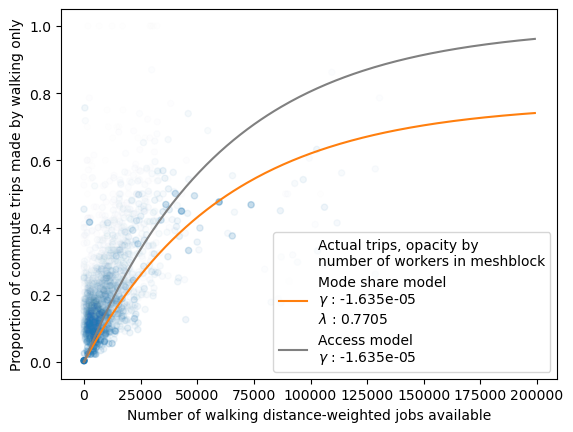

In [44]:
fig, ax = plt.subplots()
ax.scatter(data.loc[subdata, 'Jobs_mean'], data.loc[subdata, 'Walked only']/data.loc[subdata, 'total_workers'],
           #c=data.loc[subdata, 'total_workers'], cmap='Reds',
           alpha=data.loc[subdata, 'total_workers']/max(data.loc[subdata, 'total_workers']),
           c='#1f77b4',
           s=20, label="Actual trips, opacity by \nnumber of workers in meshblock")
ax.plot(model_jobs_short, (1 - np.exp(model_jobs_short*exp2wp.x[0]))*exp2wp.x[1], 
        label=("Mode share model \n" +
               r'$\gamma$ : '+str(exp2wp.x[0].round(8)) + "\n"+ 
               r'$\lambda$ : '+ str(exp2wp.x[1].round(4))),
       c='#ff7f0e')
ax.plot(model_jobs_short, (1 - np.exp(model_jobs_short*exp2wp.x[0])), 
        label=("Access model \n" + 
        r'$\gamma$ : '+str(exp2wp.x[0].round(8))),
       c='grey')

ax.legend(loc ="lower right")
ax.set_ylabel('Proportion of commute trips made by walking only')
ax.set_xlabel('Number of walking distance-weighted jobs available')

plt.savefig("commute_mode_model.pdf", format = 'pdf')

Text(0.5, 0, 'Number of walking distance-weighted jobs available')

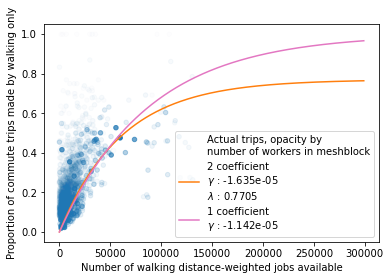

In [104]:
fig, ax = plt.subplots()
ax.scatter(data.loc[subdata, 'Jobs_mean'], data.loc[subdata, 'Walked only']/data.loc[subdata, 'total_workers'],
           #c=data.loc[subdata, 'total_workers'], cmap='Reds',
           alpha=data.loc[subdata, 'total_workers']/max(data.loc[subdata, 'total_workers']),
           c='#1f77b4',
           s=20, label="Actual trips, opacity by \nnumber of workers in meshblock")
ax.plot(model_jobs, (1 - np.exp(model_jobs*exp2wp.x[0]))*exp2wp.x[1], 
        label=("2 coefficient\n" +
               r'$\gamma$ : '+str(exp2wp.x[0].round(8)) + "\n"+ 
               r'$\lambda$ : '+ str(exp2wp.x[1].round(4))),
       c='#ff7f0e')
ax.plot(model_jobs, (1 - np.exp(model_jobs*exp1wp.x[0])), 
        label=("1 coefficient \n" + 
        r'$\gamma$ : '+str(exp1wp.x[0].round(8))),
       c='#e377c2')

ax.legend(loc ="lower right")
ax.set_ylabel('Proportion of commute trips made by walking only')
ax.set_xlabel('Number of walking distance-weighted jobs available')

Text(0.5, 0, 'Number of walking distance-weighted jobs available')

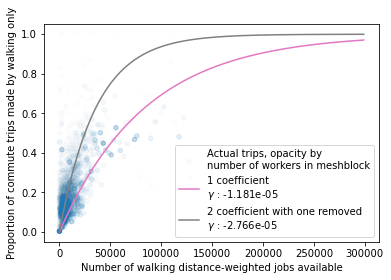

In [39]:
fig, ax = plt.subplots()
ax.scatter(data.loc[subdata, 'Jobs_mean'], data.loc[subdata, 'Walked only']/data.loc[subdata, 'total_workers'],
           #c=data.loc[subdata, 'total_workers'], cmap='Reds',
           alpha=data.loc[subdata, 'total_workers']/max(data.loc[subdata, 'total_workers']),
           c='#1f77b4',
           s=20, label="Actual trips, opacity by \nnumber of workers in meshblock")
ax.plot(model_jobs, (1 - np.exp(model_jobs*exp1p.x[0])), 
        label=("1 coefficient \n" + 
        r'$\gamma$ : '+str(exp1p.x[0].round(8))),
       c='#e377c2')
ax.plot(model_jobs, (1 - np.exp(model_jobs*exp2p.x[0])), 
        label=("2 coefficient with one removed \n" + 
        r'$\gamma$ : '+str(exp2p.x[0].round(8))),
       c='grey')

#ax.scatter(data10['Jobs_mean'], exp2_model(exp2wp.x, total_workers, jobs)/data10['total_workers'])
#ax.scatter(data10['Jobs_mean'], exp1_model(exp1wp.x, total_workers, jobs)/data10['total_workers'])
#ax.scatter(data10['Jobs_mean'], flat_model(flatp.x, total_workers)/data10['total_workers'])
ax.legend(loc ="lower right")
ax.set_ylabel('Proportion of commute trips made by walking only')
ax.set_xlabel('Number of walking distance-weighted jobs available')

Text(0.5, 0, 'Predicted walk trips')

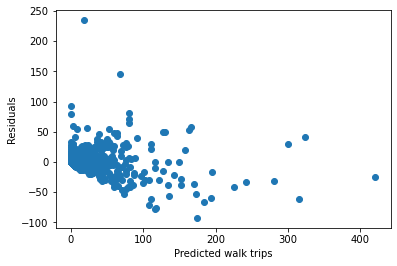

In [40]:
estimate = total_workers*(1 - np.exp(jobs*exp1wp.x[0]))
fig, ax = plt.subplots()
ax.scatter(total_workers*(1 - np.exp(jobs*exp1p.x[0])), exp1(exp1p.x))
ax.set_ylabel('Residuals')
ax.set_xlabel('Predicted walk trips')

Text(0.5, 0, 'Number of walking distance-weighted jobs available')

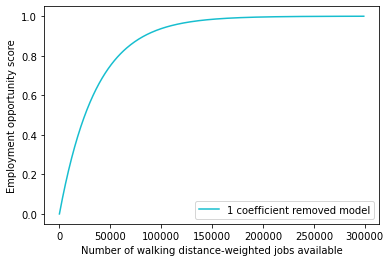

In [41]:
fig, ax = plt.subplots()
ax.plot(model_jobs, (1 - np.exp(model_jobs*exp2p.x[0])), label="1 coefficient removed model",
       c='#17becf')
ax.legend(loc ="lower right")
ax.set_ylabel('Employment opportunity score')
ax.set_xlabel('Number of walking distance-weighted jobs available')

In [42]:
np.mean(data[data['Jobs_mean']>111750]['walk_prop'])

0.49233991329281246

In [43]:
len(data[data['Jobs_mean']<40000])/len(data)

0.9967428860670349

In [53]:
math.log((1-0.8))/0.000017, math.log((1-0.8))/exp2p.x[0], math.log((1-0.8))/exp1p.x[0]

(-94672.8183784765, 58180.105302527474, 136269.97022182454)

In [ ]:
np.exp(model_jobs*exp2p.x[0]) = ln(1 - 0.8)

## Validate with Melbourne

In [81]:
folder = "C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Colouring data & results\\Melbourne Data\\"
melb_features = pd.read_csv(folder + "Colouring_bf_results_020522_round.csv")
melb_features = gpd.GeoDataFrame(melb_features, 
                 geometry=gpd.points_from_xy(melb_features.x, melb_features.y, crs="EPSG:7855"))

melb_mbs = gpd.read_file(folder + "Data\\2016_VIC_MBs\\MB_2016_VIC.shp")
melb_mbs = melb_mbs.to_crs("EPSG:7855")

In [82]:
melb_mode_data = pd.read_csv("C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Data\\ABS Data\\Inner Melbourne MBs Work Travel Mode.csv")

melb_mode_data = melb_mode_data.pivot(index = 'MB',  columns = 'MTWP Method of Travel to Work', values = 'Count')

<ipython-input-82-1b87c80ef31b>:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  melb_mode_data = pd.read_csv("C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Data\\ABS Data\\Inner Melbourne MBs Work Travel Mode.csv")


In [83]:
melb_features_joined = gpd.sjoin(melb_features, melb_mbs, how='inner', predicate='intersects')

melb_mb_features = melb_features_joined.groupby(['MB_CODE16']).mean()

melb_mb_features.index = melb_mb_features.index.astype('int64')

melb_data = melb_mb_features.join(melb_mode_data, on="MB_CODE16")
melb_data = melb_data.dropna()

In [84]:
melb_data['total_workers'] = melb_data.iloc[:,np.r_[44:81, 83:91,96:105, 107:165]].sum(axis=1)
melb_data = melb_data[melb_data['total_workers']>0]

In [123]:
estimate = exp2_model(exp2p.x, melb_data['total_workers'], melb_data['jobs'])
get_rsq(estimate/melb_data['total_workers'], melb_data['Walked only']/melb_data['total_workers']), get_rsq(estimate, melb_data['Walked only'])

(0.31326018977236814, 0.8588531903033285)

In [118]:
exp2wp.x

array([-1.63536767e-05,  7.70457207e-01])

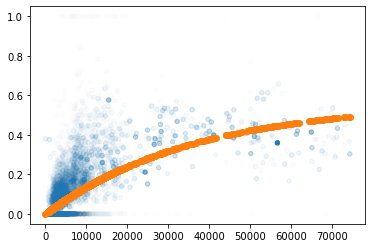

In [86]:
fig, ax = plt.subplots()
ax.scatter(melb_data['jobs'], melb_data['Walked only']/melb_data['total_workers'],
          alpha=melb_data['total_workers']/max(melb_data['total_workers']),
           c='#1f77b4',
           s=20, label="Actual trips, opacity by \nnumber of workers in meshblock")
ax.scatter(melb_data['jobs'], estimate/melb_data['total_workers'],
          label=("2 coefficient\n" +
               r'$\gamma$ : '+str(exp2p.x[0].round(8)) + "\n"+ 
               r'$\lambda$ : '+ str(exp2p.x[1].round(4))),
               c='#ff7f0e')

In [122]:
estimate_w = exp2w_model(exp2wp.x, melb_data['total_workers'], melb_data['jobs'])
get_rsq(estimate_w, melb_data['Walked only'])

0.8276866489416835

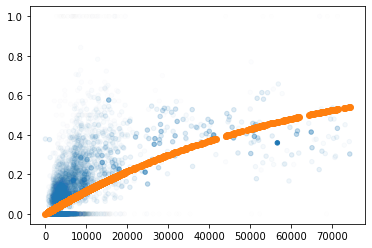

In [121]:
fig, ax = plt.subplots()
ax.scatter(melb_data['jobs'], melb_data['Walked only']/melb_data['total_workers'],
          alpha=melb_data['total_workers']/max(melb_data['total_workers']),
           c='#1f77b4',
           s=20, label="Actual trips, opacity by \nnumber of workers in meshblock")
ax.scatter(melb_data['jobs'], estimate_w/melb_data['total_workers'],
          label=("2 coefficient\n" +
               r'$\gamma$ : '+str(exp2wp.x[0].round(8)) + "\n"+ 
               r'$\lambda$ : '+ str(exp2wp.x[1].round(4))),
               c='#ff7f0e')

In [87]:
len(melb_data)

5958

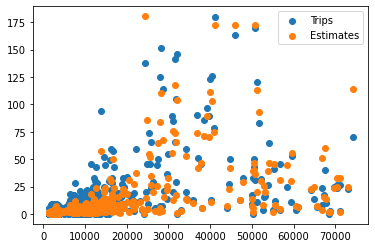

In [88]:
fig, ax = plt.subplots()
ax.scatter(melb_data['jobs'][0:1000], melb_data['Walked only'][0:1000],label = 'Trips')
ax.scatter(melb_data['jobs'][0:1000], estimate[0:1000], label = 'Estimates')
ax.legend()

In [89]:
get_rsq(estimate/melb_data['total_workers'], melb_data['Walked only']/melb_data['total_workers'])

0.31326018977236814

In [90]:
get_rsq(estimate, melb_data['Walked only'])

0.8588531903033285

In [629]:
np.mean(melb_data[melb_data['jobs'] > 20000]['Walked only']/melb_data[melb_data['jobs'] > 20000]['total_workers'])

0.3956864908374159

In [630]:
np.mean(melb_data[melb_data['jobs'] > 10000]['Walked only']/melb_data[melb_data['jobs'] > 10000]['total_workers'])

0.31389581551040674

In [626]:
melb_data.to_csv('Inner Melb MBs joined modes features.csv')

### Newcastle

In [4]:
folder = "C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Colouring data & results\\"
data = "C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Data\\"
newcastle_features = gpd.read_file(folder + "Newcastle MB results walk 170822.gpkg").to_crs("EPSG:7855")

nsw_mbs = gpd.read_file(data + "ABS Data\\MBs\\2016_NSW_MBs\\MB_2016_NSW_counts.gpkg")
nsw_mbs = nsw_mbs.to_crs("EPSG:7855")

In [5]:
newcastle_mode_data = pd.read_csv(data + "ABS Data\\Newcastle+MBs+MTWP\\Newcastle MBs MTWP.csv")

newcastle_mode_data = newcastle_mode_data.pivot(index = 'MB',  columns = 'MTWP Method of Travel to Work', values = 'Count')

<ipython-input-5-fd791b821972>:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  newcastle_mode_data = pd.read_csv(data + "ABS Data\\Newcastle+MBs+MTWP\\Newcastle MBs MTWP.csv")


In [38]:
newcastle_mb_features

,AREASQKM16_left,AREA_ALBERS_SQKM,Dwelling,Person,State,index_walk,x,y,Jobs,employment_31.9,...,recreation2,recreation3,recreation4,recreation5,THERE_Index,index_right,AREASQKM16_right,2016 census mesh block counts_AREA_ALBERS_SQKM,2016 census mesh block counts_Dwelling,2016 census mesh block counts_Person
MB_CODE16_left,,,,,,,,,,,,,,,,,,,,,
10430860000,0.0384,0.0384,47.0,99.0,1.0,5.298812e+09,372026.231946,6.346557e+06,97.0,0.051,...,138.0,586.0,586.0,633.0,24.765,40017.0,0.0384,0.0384,47.0,99.0
10430870000,0.0347,0.0347,30.0,88.0,1.0,2.766476e+08,372056.883528,6.338879e+06,235.0,0.124,...,629.0,667.0,682.0,704.0,30.573,40018.0,0.0347,0.0347,30.0,88.0
10430880000,0.0334,0.0334,39.0,127.0,1.0,2.414198e+09,372240.488538,6.346536e+06,123.0,0.065,...,503.0,503.0,520.0,520.0,25.697,40019.0,0.0334,0.0334,39.0,127.0
10430890000,0.0276,0.0276,33.0,62.0,1.0,2.766478e+08,372267.741667,6.337620e+06,272.0,0.143,...,365.0,365.0,407.0,669.0,34.277,40020.0,0.0276,0.0276,33.0,62.0
10430910000,0.0320,0.0320,45.0,122.0,1.0,2.766477e+08,372241.928499,6.338494e+06,380.0,0.200,...,503.0,526.0,585.0,585.0,35.532,40021.0,0.0320,0.0320,45.0,122.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11205872000,0.0614,0.0614,51.0,180.0,1.0,3.739929e+09,373145.530699,6.362709e+06,236.0,0.124,...,363.0,416.0,416.0,426.0,24.847,109392.0,0.0614,0.0614,51.0,180.0
11205873300,0.0652,0.0652,0.0,0.0,1.0,3.553825e+08,385623.168667,6.355044e+06,3852.0,1.968,...,45.0,63.0,325.0,325.0,57.840,109405.0,0.0652,0.0652,0.0,0.0
11205873400,0.0931,0.0931,0.0,0.0,1.0,3.691717e+08,372608.044320,6.361101e+06,190.0,0.100,...,404.0,463.0,466.0,1581.0,23.678,109406.0,0.0931,0.0931,0.0,0.0


In [33]:
newcastle_features_joined = gpd.sjoin(newcastle_features, nsw_mbs, how='inner', predicate='intersects')

In [36]:
newcastle_mb_features = newcastle_features_joined.groupby(['MB_CODE16_left']).mean()

newcastle_mb_features.index = newcastle_mb_features.index.astype('int64')

In [39]:
newcastle_data = newcastle_mb_features.join(newcastle_mode_data, on="MB_CODE16_left")
newcastle_data = newcastle_data.dropna()

In [40]:
newcastle_data['total_workers'] = newcastle_data.iloc[:,np.r_[44:81, 83:91,96:105, 107:165]].sum(axis=1)
newcastle_data = newcastle_data[newcastle_data['total_workers']>0]

In [65]:
newcastle_data = newcastle_data[newcastle_data['total_workers']>=newcastle_data['Walked only']]

In [69]:
estimate = exp2_model(exp2p.x, newcastle_data['total_workers'], newcastle_data['Jobs'])

(0.0, 0.2)

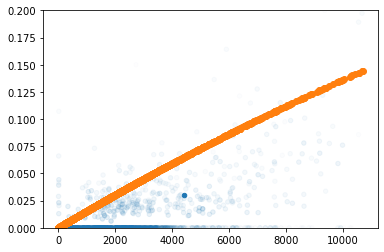

In [71]:
fig, ax = plt.subplots()
ax.scatter(newcastle_data['Jobs'], newcastle_data['Walked only']/newcastle_data['total_workers'],
          alpha=newcastle_data['total_workers']/max(newcastle_data['total_workers']),
           c='#1f77b4',
           s=20, label="Actual trips, opacity by \nnumber of workers in meshblock")
ax.scatter(newcastle_data['Jobs'], estimate/newcastle_data['total_workers'],
          label=("2 coefficient\n" +
               r'$\gamma$ : '+str(exp2p.x[0].round(8)) + "\n"+ 
               r'$\lambda$ : '+ str(exp2p.x[1].round(4))),
               c='#ff7f0e')
plt.ylim([0, 0.2])

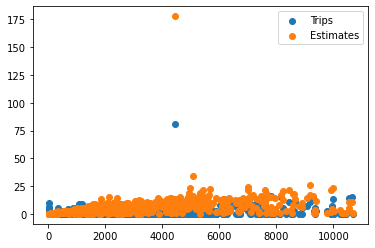

In [73]:
fig, ax = plt.subplots()
ax.scatter(newcastle_data['Jobs'][0:1000], newcastle_data['Walked only'][0:1000],label = 'Trips')
ax.scatter(newcastle_data['Jobs'][0:1000], estimate[0:1000], label = 'Estimates')
ax.legend()

In [74]:
get_rsq(estimate/newcastle_data['total_workers'], newcastle_data['Walked only']/newcastle_data['total_workers'])

-0.6407893575740742

In [78]:
np.mean(newcastle_data[newcastle_data['Jobs'] > 8000]['Walked only']/newcastle_data[newcastle_data['Jobs'] > 8000]['total_workers'])

0.07599205068952644

In [80]:
np.mean(newcastle_data[newcastle_data['Jobs'] > 6000]['Walked only']/newcastle_data[newcastle_data['Jobs'] > 6000]['total_workers'])

0.045999018901180896